# Checking timing with photodiode

This notebook shows how to check the delay between the triggers and the onset of the visual stimuli. 

It also shows you how to adjust the trigger timing, to account for this difference when creating epochs, by adjusting the sample column of the `events`. 

In [1]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
%matplotlib widget 

# importing from your local utils
import sys
sys.path.append("../scripts")
from utils.photodiode import rising_edges
from params import fnames, DATES, EVENT_ID, EVENTS_MIN_DURATION

In [2]:
subject = "0195"
date = DATES.get(subject)

raw_sub_path = fnames.sub_raw(subject=subject, date=date)
raw = mne.io.read_raw_fif(raw_sub_path)

Opening raw data file /work/raw/0195/20260910_000000/workshop_2026_raw.fif...
    Read a total of 9 projection items:
        planar-Raw-0.000-120.000-PCA-01 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-02 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-03 (1 x 203)  idle
        axial-Raw-0.000-120.000-PCA-01 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-02 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-03 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-04 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-05 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-06 (1 x 102)  idle
    Range : 200000 ... 1796999 =    200.000 ...  1796.999 secs
Ready.
Opening raw data file /work/raw/0195/20260910_000000/workshop_2026_raw-1.fif...
    Read a total of 9 projection items:
        planar-Raw-0.000-120.000-PCA-01 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-02 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-03 (1 x 203)  idle
        axial-Raw-0.000-12

## Estimating delay

In [3]:
events = mne.find_events(raw, min_duration=EVENTS_MIN_DURATION)

Finding events on: STI101
2400 events found on stim channel STI101
Event IDs: [ 1  3  4  6  8 10 12 14 16]


Using matplotlib as 2D backend.


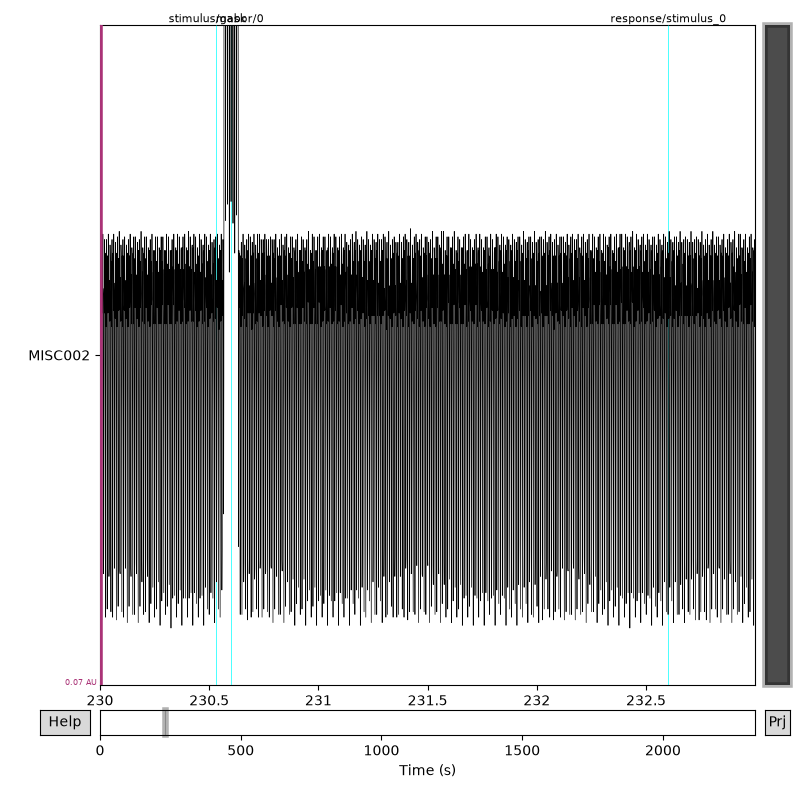

In [4]:
plot = raw.plot(picks="MISC002", events=events, start=230, duration=3, event_id=EVENT_ID);

We see a delay between when the trigger was sent to the MEG system and when the photodiode is on. We can account for this delay, but first we need to make sure, that it is constant. 

In [5]:
photodiode_data = raw.get_data(picks="MISC002").squeeze()

photodiode_trigs = rising_edges(photodiode_data, raw.info["sfreq"])
photodiode_trigs = photodiode_trigs + raw.first_samp

Just to verify, we plot the events detected from the photodiode. Looking at the plot, they seem to line up nicely!

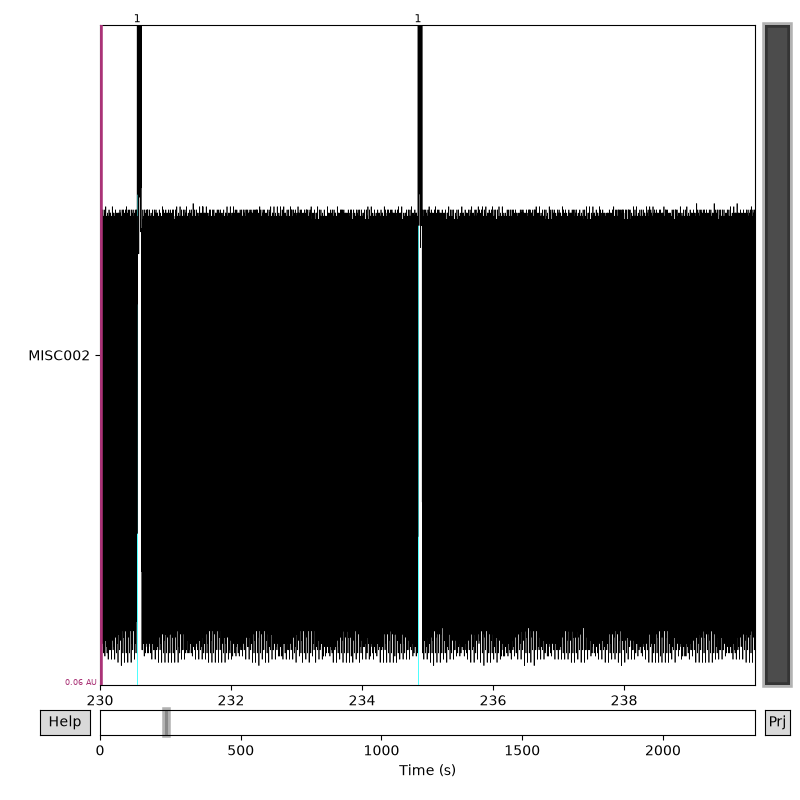

In [6]:
photodiode_events = np.array([photodiode_trigs, [0]*len(photodiode_trigs), [1]*len(photodiode_trigs)]).T
raw.plot(picks="MISC002", events=photodiode_events, start=230, duration=10);

In [7]:
# find the trigger values for the events with photodiode (the gabor patches)
stim_trigs = [1, 3]
events_stim = np.array([event for event in events if event[-1] in stim_trigs])

In [8]:
# compare event timing from photodiode and triggers
diff = []

for event in events_stim:
    samp = event[0]

    # find the nearest matching photodiode event
    difference = np.abs(photodiode_trigs - samp)
    idx = difference.argmin()
    diff.append(photodiode_trigs[idx]-samp)

In [9]:
# count each of the occurences 
np.unique(diff, return_counts=True)

(array([35, 36, 37, 38]), array([ 56, 328, 214,   2]))

In [12]:
events[:, 0] = events[:, 0] + 36 # adding 36 as it is the mode

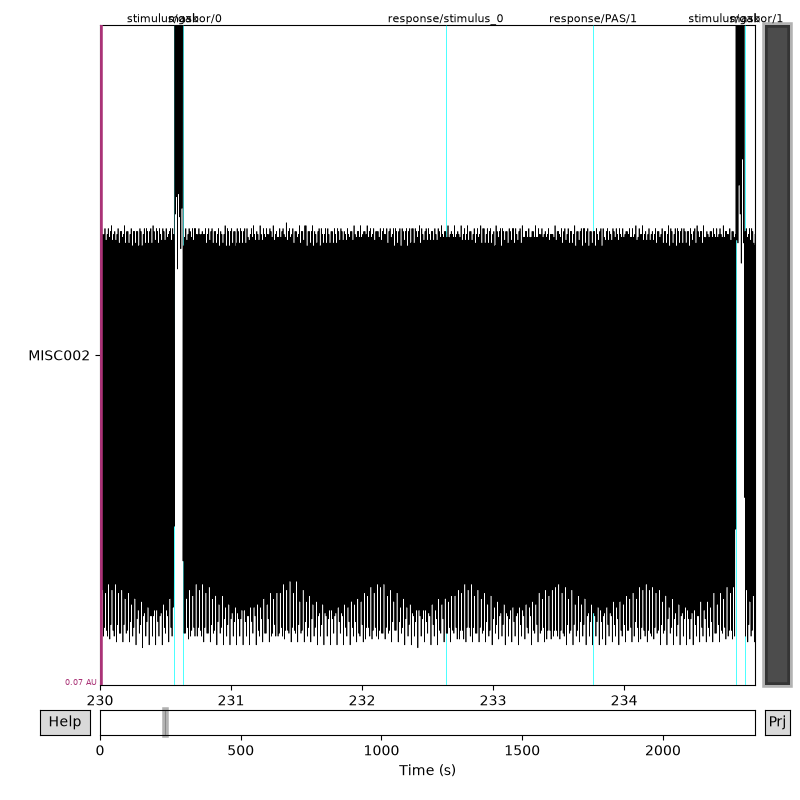

In [11]:
# lets plot to see if it looks good!
raw.plot(picks="MISC002", events=events, start=230, duration=5, event_id=EVENT_ID);

## Checking duration of stimulation
You can play around with adding some code for checking the duration of the stimuli as well! 